In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adityaaryan526/mmhs-dataset/MMHS/MMHS150K_GT.json
/kaggle/input/datasets/adityaaryan526/jigsaw/Jigsaw/sample_submission.csv
/kaggle/input/datasets/adityaaryan526/jigsaw/Jigsaw/test_labels.csv
/kaggle/input/datasets/adityaaryan526/jigsaw/Jigsaw/train.csv
/kaggle/input/datasets/adityaaryan526/jigsaw/Jigsaw/test.csv
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /.gitignore
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /english/english_2019_1.tsv
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /english/english_2020.xlsx
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /english/en_Hasoc2021_test_task1.csv
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /english/english_2021.csv
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /english/english_2019_2.tsv
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /hindi/hindi_2019_1.tsv
/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC /hindi/hindi_202

## 🌐 Multilingual Toxicity Classifier

This project builds a multilingual toxicity detection system using transformer models.

It detects:
- Toxic
- Obscene
- Insult
- Identity hate
- Threat
- Severe toxicity

The system supports English and Hinglish (code-mixed Hindi-English) and includes explainability techniques like attention and gradient-based attribution.

In [2]:
!pip install transformers datasets openpyxl -q

## 📚 Importing Required Libraries

This cell imports all the necessary libraries for data processing, model training, evaluation, and visualization.  
It includes PyTorch, HuggingFace Transformers, NumPy, Pandas, and Scikit-learn.

In [3]:
import pandas as pd
import numpy as np
import torch
import os
import re
import json

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

import matplotlib.pyplot as plt

## 🧹 Text Cleaning

We define a function to clean raw text by:
- Removing URLs
- Normalizing text
- Preparing data for model input

In [4]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

## 📂 Loading Datasets

In this step, we load multiple datasets:
- Jigsaw Toxic Comment Dataset (English)
- HASOC Dataset (English + Hindi)
- MMHS Dataset (Multimodal Hate Speech - text only)

These datasets provide diverse examples of toxic and non-toxic content.

In [5]:
jigsaw = pd.read_csv('/kaggle/input/datasets/adityaaryan526/jigsaw/Jigsaw/train.csv')

jigsaw = jigsaw[[
    'comment_text',
    'toxic','obscene','insult','identity_hate','threat','severe_toxic'
]]

jigsaw.columns = [
    'text','toxic','obscene','insult','identity_hate','threat','severe_toxic'
]

jigsaw['text'] = jigsaw['text'].apply(clean_text)
jigsaw['source'] = 'jigsaw'

print("Jigsaw:", jigsaw.shape)

Jigsaw: (159571, 8)


In [6]:
hasoc_data = []

base_path = "/kaggle/input/datasets/adityaaryan526/hasoc-dataset/HASOC "

def map_hasoc(label):
    if label == 0:
        return [0,0,0,0,0,0]
    else:
        return [1,0,1,0,0,0]

for root, dirs, files in os.walk(base_path):
    for file in files:
        
        file_path = os.path.join(root, file)
        
        try:
            if file.endswith(".tsv"):
                df = pd.read_csv(file_path, sep='\t')
            elif file.endswith(".csv"):
                df = pd.read_csv(file_path)
            elif file.endswith(".xlsx"):
                df = pd.read_excel(file_path)
            else:
                continue
            
            text_col = None
            label_col = None
            
            for col in df.columns:
                if 'text' in col.lower():
                    text_col = col
                if 'task_1' in col.lower() or 'label' in col.lower():
                    label_col = col
            
            if text_col and label_col:
                temp = df[[text_col, label_col]].copy()
                temp.columns = ['text', 'label']
                
                temp['text'] = temp['text'].apply(clean_text)
                
                temp[['toxic','obscene','insult','identity_hate','threat','severe_toxic']] = \
                pd.DataFrame(temp['label'].apply(map_hasoc).tolist(), index=temp.index)
                
                temp = temp.drop(columns=['label'])
                temp['source'] = 'hasoc'
                
                hasoc_data.append(temp)
        
        except:
            continue

hasoc = pd.concat(hasoc_data, ignore_index=True)

print("HASOC:", hasoc.shape)

HASOC: (21425, 8)


In [7]:
with open('/kaggle/input/datasets/adityaaryan526/mmhs-dataset/MMHS/MMHS150K_GT.json') as f:
    data = json.load(f)

texts = []
labels = []

def map_mmhs(label_list):
    if all(l == 0 for l in label_list):
        return [0,0,0,0,0,0]
    else:
        return [1,0,1,1,0,0]

for key in data:
    item = data[key]
    
    text = item.get("tweet_text", "")
    label_list = item.get("labels", [])
    
    texts.append(clean_text(text))
    labels.append(map_mmhs(label_list))

mmhs = pd.DataFrame(texts, columns=["text"])

mmhs[['toxic','obscene','insult','identity_hate','threat','severe_toxic']] = pd.DataFrame(labels)

mmhs['source'] = 'mmhs'

print("MMHS:", mmhs.shape)

MMHS: (149823, 8)


## 🔗 Merging Datasets

We combine all datasets into a single unified dataset to improve diversity and generalization.

In [8]:
df = pd.concat([jigsaw, hasoc, mmhs], ignore_index=True)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Final Dataset:", df.shape)

Final Dataset: (330819, 8)


## 🏷️ Label Definition

We define the six toxicity labels used for multi-label classification.

In [9]:
label_cols = ['toxic','obscene','insult','identity_hate','threat','severe_toxic']

texts = df['text'].tolist()
labels = df[label_cols].values

## ✂️ Train-Test Split

We split the dataset into training and validation sets to evaluate model performance.

In [10]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.1, random_state=42
)

🧠 MODEL PIPELINE

## 🧱 Custom Dataset Class

We create a PyTorch dataset to:
- Tokenize text
- Convert labels into tensors
- Feed data into the model efficiently

In [11]:
class ToxicDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts, truncation=True, padding=False, max_length=96)
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)

## 📦 Data Collator

We use dynamic padding to efficiently batch inputs of different lengths.

In [12]:
from transformers import DataCollatorWithPadding

def get_data_collator(tokenizer):
    return DataCollatorWithPadding(tokenizer=tokenizer)

## 📊 Evaluation Metrics

We compute:
- F1 (micro & macro)
- Precision & Recall
- Per-label F1 scores

F1 is preferred due to class imbalance.

In [93]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = (torch.sigmoid(torch.tensor(logits)) > 0.5).int().numpy()

    results = {
        "f1_micro": f1_score(labels, preds, average="micro"),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

    label_names = ['toxic','obscene','insult','identity_hate','threat','severe_toxic']
    
    for i, name in enumerate(label_names):
        results[f"f1_{name}"] = f1_score(labels[:, i], preds[:, i])
    
    return results

## 🤖 Training Function

This function:
- Loads pretrained transformer models
- Trains using HuggingFace Trainer
- Evaluates performance

In [14]:
def train_model(model_name):

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    data_collator = get_data_collator(tokenizer)

    train_dataset = ToxicDataset(train_texts, train_labels, tokenizer)
    val_dataset = ToxicDataset(val_texts, val_labels, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=6,
        problem_type="multi_label_classification"
    )
 
    training_args = TrainingArguments(
        output_dir=f"/kaggle/working/{model_name}",
        eval_strategy="epoch",
        save_strategy="no",
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=2,
        learning_rate=2e-5,
        logging_steps=500,
        fp16=True,
        dataloader_num_workers=2,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator   # 🔥 IMPORTANT
    )

    trainer.train()

    return trainer, trainer.evaluate()

## 🟦 Training mBERT

We train the multilingual BERT model and evaluate its performance.

In [15]:
mbert_trainer, mbert_results = train_model("bert-base-multilingual-cased")
print(mbert_results)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,F1 Toxic,F1 Obscene,F1 Insult,F1 Identity Hate,F1 Threat,F1 Severe Toxic
1,0.348987,0.347628,0.742815,0.495980,0.765202,0.746462,0.745860,0.718354,0.000000,0.000000
2,0.327213,0.342683,0.728387,0.565565,0.748688,0.756501,0.739553,0.690733,0.000000,0.457912


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.34268349409103394, 'eval_f1_micro': 0.7283865002311605, 'eval_f1_macro': 0.5655646912021548, 'eval_f1_toxic': 0.7486883735832432, 'eval_f1_obscene': 0.7565011820330969, 'eval_f1_insult': 0.739553375063441, 'eval_f1_identity_hate': 0.6907327586206896, 'eval_f1_threat': 0.0, 'eval_f1_severe_toxic': 0.45791245791245794, 'eval_runtime': 136.6122, 'eval_samples_per_second': 242.16, 'eval_steps_per_second': 3.784, 'epoch': 2.0}


## 🟥 Training XLM-R

We train XLM-Roberta, which is optimized for multilingual data, and compare results with mBERT.

In [16]:
xlmr_trainer, xlmr_results = train_model("xlm-roberta-base")
print(xlmr_results)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather alon

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,F1 Toxic,F1 Obscene,F1 Insult,F1 Identity Hate,F1 Threat,F1 Severe Toxic
1,0.349993,0.346539,0.734216,0.516103,0.753150,0.741954,0.738571,0.712188,0.000000,0.150754
2,0.331302,0.340274,0.724339,0.568033,0.748311,0.749718,0.736097,0.680170,0.000000,0.493902


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.34027376770973206, 'eval_f1_micro': 0.7243393109957527, 'eval_f1_macro': 0.5680329801354006, 'eval_f1_toxic': 0.7483109483109484, 'eval_f1_obscene': 0.7497181510710259, 'eval_f1_insult': 0.7360967184801381, 'eval_f1_identity_hate': 0.6801696239259011, 'eval_f1_threat': 0.0, 'eval_f1_severe_toxic': 0.49390243902439024, 'eval_runtime': 156.3875, 'eval_samples_per_second': 211.539, 'eval_steps_per_second': 3.306, 'epoch': 2.0}


## ⚖️ Model Comparison

We compare both models across multiple metrics to determine performance differences.

In [95]:
comparison = pd.DataFrame({
    "Metric": list(mbert_results.keys()),
    "mBERT": list(mbert_results.values()),
    "XLM-R": list(xlmr_results.values())
})

comparison

,Metric,mBERT,XLM-R
0,eval_loss,0.342683,0.340274
1,eval_f1_micro,0.728387,0.724339
2,eval_f1_macro,0.565565,0.568033
3,eval_f1_toxic,0.748688,0.748311
4,eval_f1_obscene,0.756501,0.749718
5,eval_f1_insult,0.739553,0.736097
6,eval_f1_identity_hate,0.690733,0.680170
7,eval_f1_threat,0.000000,0.000000
8,eval_f1_severe_toxic,0.457912,0.493902
9,eval_runtime,136.612200,156.387500


🔥 VISUALIZATION

In [26]:
def plot_confusion_matrices(trainer, val_dataset):
    preds = trainer.predict(val_dataset)
    
    y_pred = (torch.sigmoid(torch.tensor(preds.predictions)) > 0.5).int().numpy()
    
    for i, label in enumerate(label_cols):
        cm = confusion_matrix(val_labels[:, i], y_pred[:, i])
        
        plt.figure()
        plt.imshow(cm)
        plt.title(f"{label}")
        plt.colorbar()
        plt.show()

## 📉 Confusion Matrix

We visualize confusion matrices for each label to analyze model errors and performance.

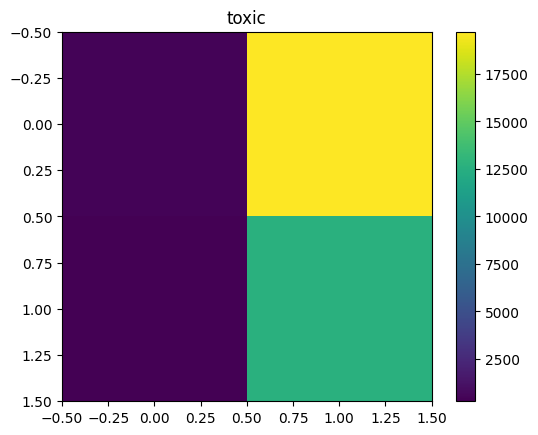

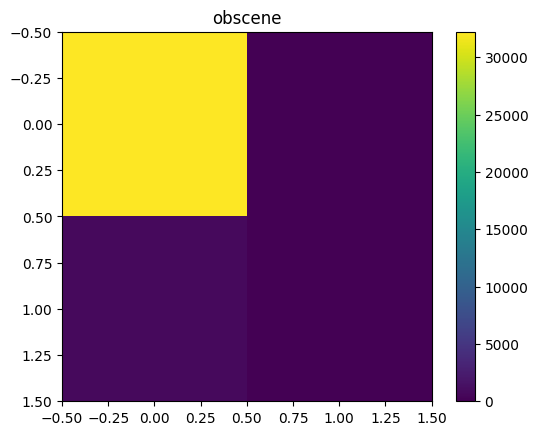

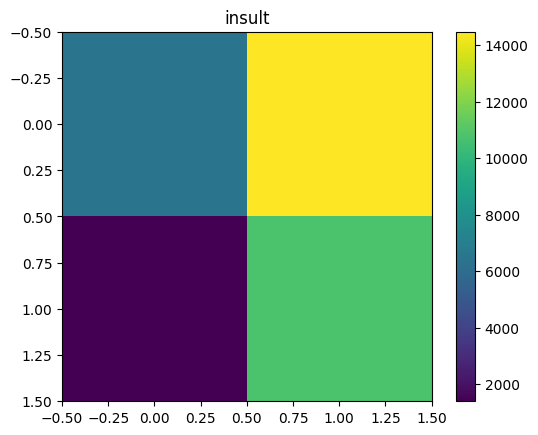

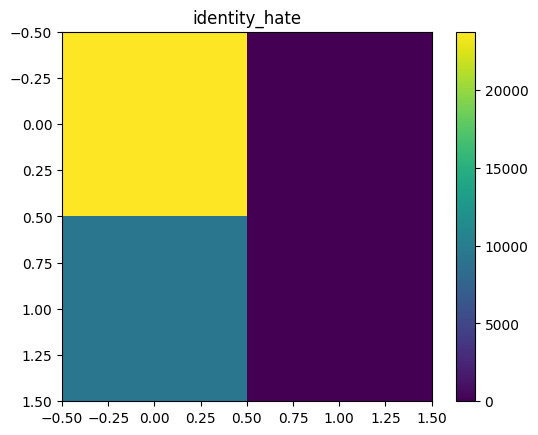

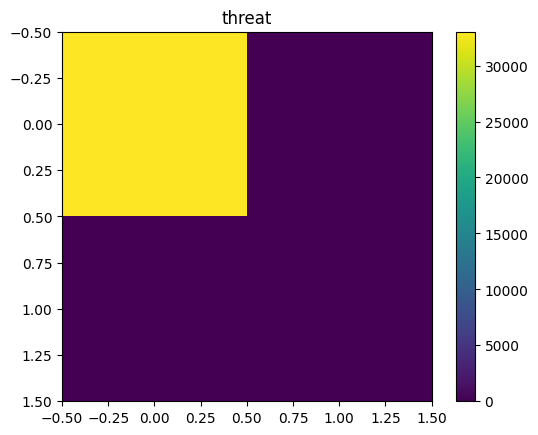

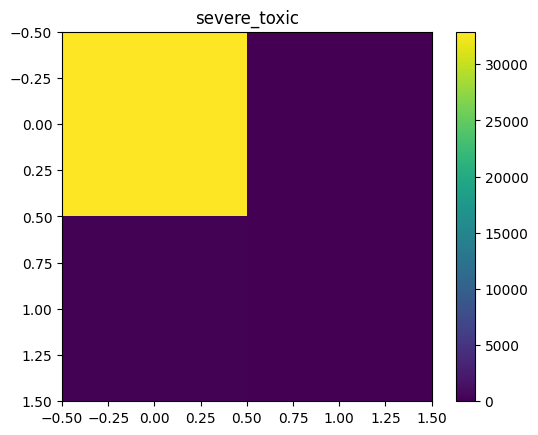

In [27]:
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
val_dataset = ToxicDataset(val_texts, val_labels, tokenizer)

plot_confusion_matrices(xlmr_trainer, val_dataset)

## 👁️ Attention Visualization

We analyze attention weights to understand which tokens the model focuses on.

In [42]:
def show_attention(text, model, tokenizer):
    
    import torch
    
    device = next(model.parameters()).device

    # 🔥 Fix for attention extraction (SDPA issue)
    model.config._attn_implementation = "eager"

    inputs = tokenizer(text, return_tensors="pt", truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()

    with torch.no_grad():
        outputs = model(
            **inputs,
            output_attentions=True,
            return_dict=True
        )

    # 🔥 Get last layer attention
    attentions = outputs.attentions[-1]  # shape: (batch, heads, seq_len, seq_len)

    # 🔥 Average across heads ONLY (important)
    attentions = attentions.mean(dim=1).squeeze()  # (seq_len, seq_len)

    # 🔥 Use CLS token attention (BEST for classification)
    scores = attentions.max(dim=0).values.cpu().numpy()

    # 🔥 Convert tokens
    input_ids = inputs["input_ids"][0].cpu()
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    print("\n🔍 Word-level Attention:\n")

    # 🔥 Clean mapping to words
    words = text.split()

    # skip special tokens like <s>
    clean_scores = scores[1:len(words)+1]

    for word, score in zip(words, clean_scores):
        print(f"{word:15} → {round(float(score), 3)}")

## 🔥 Gradient-based Importance

We compute gradients to measure how much each word contributes to the prediction, providing better interpretability than attention.

In [77]:
import torch

def gradient_importance(text, model, tokenizer, return_scores=False):
    
    model.eval()
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    words = text.split()

    # Tokenize with offsets
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        return_offsets_mapping=True
    )
    
    offsets = inputs.pop("offset_mapping")[0].tolist()
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    input_ids = inputs["input_ids"]

    # 🔥 Embeddings
    embeddings = model.get_input_embeddings()(input_ids)
    embeddings = embeddings.detach()
    embeddings.requires_grad_(True)
    embeddings.retain_grad()

    outputs = model(
        inputs_embeds=embeddings,
        attention_mask=inputs["attention_mask"]
    )

    logits = outputs.logits
    score = logits[0][0]

    model.zero_grad()
    score.backward()

    grads = embeddings.grad.abs().sum(dim=-1).squeeze().detach().cpu().numpy()

    # 🔥 Map token gradients → word gradients
    word_scores = [0.0 for _ in words]

    for i, (start, end) in enumerate(offsets):
        if start == end:  # special tokens
            continue

        for j, word in enumerate(words):
            word_start = text.find(word)
            word_end = word_start + len(word)

            # overlap check
            if not (end <= word_start or start >= word_end):
                word_scores[j] += grads[i]

    # Normalize
    max_score = max(word_scores) if max(word_scores) != 0 else 1
    norm_scores = [s / max_score for s in word_scores]

    print("\n🔥 Gradient-based Importance (Word-level):\n")
    for w, s in zip(words, norm_scores):
        print(f"{w:<15} → {round(float(s),3)}")

    if return_scores:
        return norm_scores

## 🌍 Testing on Real-world Examples

We test the model on:
- English sentences
- Hinglish sentences
- Toxic and non-toxic inputs

This demonstrates robustness and real-world applicability.

In [79]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

gradient_importance(
    "you are a disgusting idiot",
    xlmr_trainer.model,
    tokenizer
)


🔥 Gradient-based Importance (Word-level):

you             → 0.822
are             → 1.0
a               → 1.0
disgusting      → 0.813
idiot           → 0.914


In [81]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

gradient_importance(
    "I hate you so much",
    xlmr_trainer.model,
    tokenizer
)


🔥 Gradient-based Importance (Word-level):

I               → 0.822
hate            → 1.0
you             → 0.792
so              → 0.813
much            → 0.914


In [82]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

gradient_importance(
    "you are a very kind person",
    xlmr_trainer.model,
    tokenizer
)


🔥 Gradient-based Importance (Word-level):

you             → 0.847
are             → 1.0
a               → 1.0
very            → 0.955
kind            → 0.864
person          → 0.997


In [83]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

gradient_importance(
    "tu bahut stupid hai",
    xlmr_trainer.model,
    tokenizer
)


🔥 Gradient-based Importance (Word-level):

tu              → 0.819
bahut           → 1.0
stupid          → 0.642
hai             → 0.772


In [84]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

gradient_importance(
    "tum ekdum useless ho",
    xlmr_trainer.model,
    tokenizer
)


🔥 Gradient-based Importance (Word-level):

tum             → 0.819
ekdum           → 1.0
useless         → 0.642
ho              → 0.772


In [85]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

gradient_importance(
    "bhai tu thoda dumb lag raha hai",
    xlmr_trainer.model,
    tokenizer
)


🔥 Gradient-based Importance (Word-level):

bhai            → 0.687
tu              → 0.762
thoda           → 0.705
dumb            → 1.0
lag             → 0.738
raha            → 0.65
hai             → 0.687


In [86]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

gradient_importance(
    "bhai tu mast kaam kar raha hai",
    xlmr_trainer.model,
    tokenizer
)


🔥 Gradient-based Importance (Word-level):

bhai            → 0.687
tu              → 0.762
mast            → 0.705
kaam            → 1.0
kar             → 0.738
raha            → 0.65
hai             → 0.687


In [90]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

gradient_importance(
    "bhai tu mental hai",
    xlmr_trainer.model,
    tokenizer
)


🔥 Gradient-based Importance (Word-level):

bhai            → 0.819
tu              → 1.0
mental          → 0.642
hai             → 0.819
